In [1]:
import pandas as pd

In [20]:
train_df = pd.read_csv("DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("DailyDelhiClimateTest.csv")

In [21]:
train_df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [22]:
test_df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [23]:
train_temp = train_df['meantemp']
test_temp = test_df['meantemp']

# Scaling

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_temp.values.reshape(-1,1))
test_scaled = scaler.transform(test_temp.values.reshape(-1,1))

# Creating Sequences

In [25]:
import numpy as np

window = 30

X_train, y_train = [], []

for i in range(window, len(train_scaled)):
    X_train.append(train_scaled[i-window:i])
    y_train.append(train_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Test  Sequences

In [26]:
total_data = np.concatenate((train_scaled, test_scaled), axis=0)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [27]:
X_test, y_test = [], []

for i in range(len(train_scaled), len(total_data)):
    X_test.append(total_data[i-window:i])
    y_test.append(total_data[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

# Training

In [28]:
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - mae: 0.0387
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - mae: 0.0380
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0377
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - mae: 0.0381
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0377
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - mae: 0.0383
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0370
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0373
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025 - mae: 0.0387
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0377
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0376
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - mae: 0.0419
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [29]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [30]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

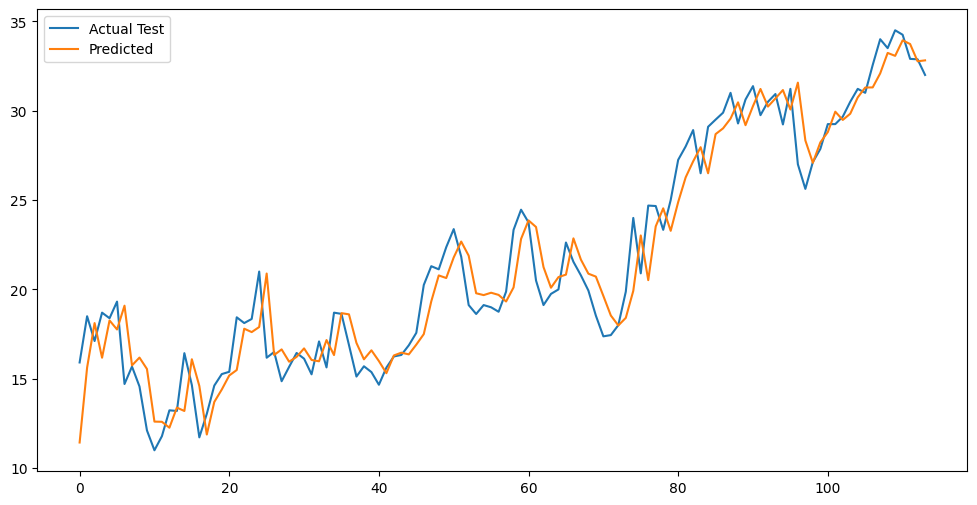

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Test")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, predictions)

rmse = mean_squared_error(y_test_actual, predictions) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.385839144673867
RMSE: 1.7771823431869365


In [34]:
predictions

array([[11.435035],
       [15.625198],
       [18.117476],
       [16.178415],
       [18.264696],
       [17.759666],
       [19.090416],
       [15.750049],
       [16.186546],
       [15.547643],
       [12.604243],
       [12.593649],
       [12.263973],
       [13.387252],
       [13.19827 ],
       [16.093231],
       [14.59975 ],
       [11.880891],
       [13.704375],
       [14.39925 ],
       [15.184791],
       [15.490681],
       [17.801985],
       [17.612751],
       [17.896688],
       [20.88903 ],
       [16.329496],
       [16.644714],
       [15.955998],
       [16.224924],
       [16.701141],
       [16.053654],
       [15.978752],
       [17.16725 ],
       [16.327261],
       [18.67236 ],
       [18.605064],
       [17.00714 ],
       [16.088898],
       [16.594002],
       [15.992233],
       [15.313154],
       [16.304909],
       [16.461615],
       [16.365643],
       [16.91176 ],
       [17.50031 ],
       [19.332163],
       [20.783188],
       [20.637941],


In [36]:
last_30_days = total_data[-30:] 

In [37]:
X_input = last_30_days.reshape(1, 30, 1)

In [38]:
next_day_scaled = model.predict(X_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [39]:
next_day_temp = scaler.inverse_transform(next_day_scaled)

print("Next day predicted temperature:", next_day_temp[0][0])

Next day predicted temperature: 32.396408
